## Customer Churn Prediction Using Machine Learning

---

##  Business Understanding

The objective of this project is to predict whether a telecom customer will churn using customer usage and account information. The dataset includes features such as account length, call usage (day, evening, and night minutes), international plan, voicemail plan, and customer service calls.

The target variable is churn, where TRUE indicates the customer left the company and FALSE indicates the customer stayed. By predicting churn early, the company can take actions such as improving customer service or offering incentives to retain customers.

---

##  Stakeholders

The main stakeholders for this project include:  
Company management, who use insights to improve business strategies and reduce churn.  
Customer retention teams, who can target customers likely to leave with special offers or improved services.  
Customer service teams, who can improve support if frequent service calls are linked to churn.

---

## Problem Description

The dataset contains customer account information, service usage details, and customer support interactions from a telecommunications company. These variables help understand customer behavior and identify factors that contribute to churn.

This project aims to answer questions such as:

Which customer behaviors are most associated with churn?

Do customers with frequent customer service calls churn more often?

Does service usage (day, evening, or night calls) influence churn?

Can customer account information and usage patterns help predict churn?

By answering these questions, the project will build a machine learning model capable of predicting customer churn.

---

## Data Understanding


In [104]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

In [79]:
df = pd.read_csv('bigml.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [80]:
# Check info about the object variables in the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [81]:
df.dtypes

state                      object
account length              int64
area code                   int64
phone number               object
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool
dtype: object

## Data Preparation:
Data preparation involves cleaning and transforming the dataset so that it can be used for machine learning models. This includes handling missing values, encoding categorical variables, scaling numerical features, and splitting the dataset into training and testing sets.


## Data Cleaning

### Checked for duplicate values

In [82]:
df.duplicated().sum()

0

### Removed irrelevant features

In [83]:
col_drop = ['phone number','state', 'area code']
df.drop(columns=col_drop, inplace=True)


In [84]:
df.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,128,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### Hadling Missing Values

In [85]:
# Check for missing values
df.isnull().sum()

account length            0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

## Exploratory Data Analysis (EDA)
The purpose of this exploratory data analysis (EDA) is to understand the structure of the dataset, identify patterns, detect relationships between variables, and determine which features are most relevant for predicting customer churn.

In [86]:
df['churn'] = df['churn'].map({True: 'Churned', False: 'Not Churned'})

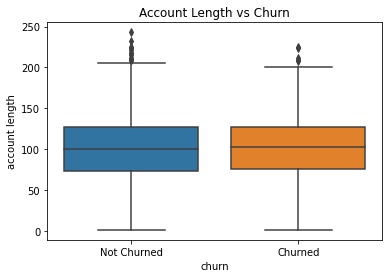

In [87]:
#Account Length by Churn Status

sns.boxplot(x='churn', y='account length', data=df)
plt.title('Account Length vs Churn')
plt.show()

the two groups look quite similar.  
Account length does not seem to strongly separate churners from non-churners. This feature may have a weak relationship with churn.

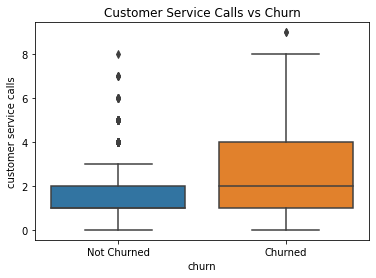

In [88]:
#Customer Service Calls by Churn Status

sns.boxplot(x='churn', y='customer service calls', data=df)
plt.title('Customer Service Calls vs Churn')
plt.show()

Customers who churn seem to have higher customer service calls.  
Customers who churn tend to contact customer service more often. This suggests service-related dissatisfaction may be an important factor in churn.

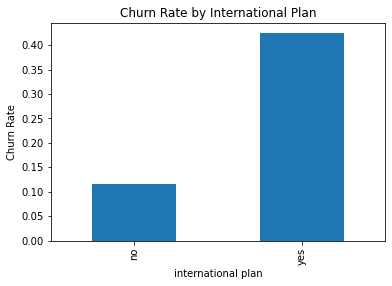

In [89]:
#International Plan vs Churn

df.groupby('international plan')['churn'] \
  .apply(lambda x: (x == 'Churned').mean()) \
  .plot(kind='bar')

plt.title('Churn Rate by International Plan')
plt.ylabel('Churn Rate')
plt.show()

Customers with an international plan appear more likely to churn than those without one. This suggests international plan status may be an important predictor of churn.

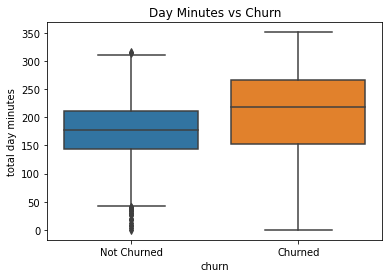

In [90]:
#Total Day Minutes by Churn Status

sns.boxplot(x='churn', y='total day minutes', data=df)
plt.title('Day Minutes vs Churn')
plt.show()

Customers who churn tend to have higher total day minutes than non-churners. This suggests heavier daytime usage may be associated with churn.

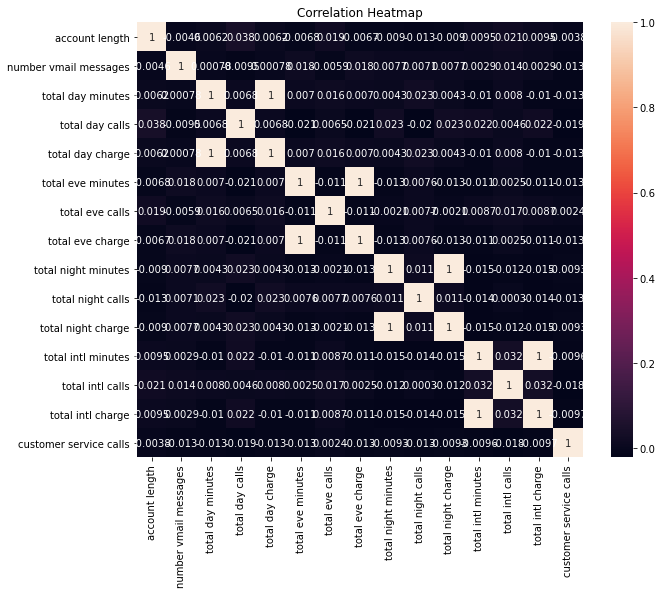

In [91]:
#Correlation between features

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

**Insight:** Strong correlations exist between minutes and corresponding charges.

**Action:** Charge-related features will be removed to reduce redundancy.

In [ ]:
#To reduce multicollinearity, the charge-related features were removed
df.drop(columns=[
    'total day charge',
    'total eve charge',
    'total night charge',
    'total intl charge'
], inplace=True)

## Modelling🚀

### Pre-process data  
Split into train and test data  
Standardise the numeric columns  
Perfom one hot encoding  
Merge the two datasets  

In [95]:
# define features and target variable
X = df.drop(columns='churn')
y = df['churn']

## Train-Test Split

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls
817,243,no,no,0,95.5,92,163.7,63,264.2,118,6.6,6,2
1373,108,no,no,0,112.0,105,193.7,110,208.9,93,4.1,4,4
679,75,yes,no,0,222.4,78,327.0,111,208.0,104,8.7,9,1
56,141,no,no,0,126.9,98,180.0,62,140.8,128,8.0,2,1
1993,86,no,no,0,216.3,96,266.3,77,214.0,110,4.5,3,0


## Perfome one hot encoding

In [107]:
#ohe_x_train 
col_ohe = ['international plan', 'voice mail plan']

col_ohe_train = X_train[col_ohe]

ohe = OneHotEncoder(sparse=False)

ohe.fit(col_ohe_train)

X_train_ohe = pd.DataFrame(
    ohe.transform(col_ohe_train),
    index=X_train.index,
    columns=ohe.get_feature_names(col_ohe)
)

X_train_ohe

,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
817,1.0,0.0,1.0,0.0
1373,1.0,0.0,1.0,0.0
679,0.0,1.0,1.0,0.0
56,1.0,0.0,1.0,0.0
1993,1.0,0.0,1.0,0.0
...,...,...,...,...
1095,1.0,0.0,1.0,0.0
1130,1.0,0.0,1.0,0.0
1294,1.0,0.0,1.0,0.0
860,1.0,0.0,1.0,0.0


In [109]:
#ohe_x_test
col_ohe_test = X_test[col_ohe]

X_test_ohe = pd.DataFrame(
    ohe.transform(col_ohe_test),   # NOT fit again!
    index=X_test.index,
    columns=ohe.get_feature_names(col_ohe)
)
X_test_ohe

,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
438,1.0,0.0,1.0,0.0
2674,1.0,0.0,1.0,0.0
1345,1.0,0.0,1.0,0.0
1957,1.0,0.0,1.0,0.0
2148,1.0,0.0,1.0,0.0
...,...,...,...,...
2577,1.0,0.0,1.0,0.0
2763,1.0,0.0,0.0,1.0
3069,1.0,0.0,0.0,1.0
1468,1.0,0.0,0.0,1.0


## Standardise the numerical columns

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    'account length',
    'number vmail messages',
    'total day minutes',
    'total day calls',
    'total eve minutes',
    'total eve calls',
    'total night minutes',
    'total night calls',
    'total intl minutes',
    'total intl calls',
    'customer service calls'
]



In [115]:
#scalled numeric features for training data
X_train_numeric = X_train[num_cols]

scaler.fit(X_train_numeric)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_numeric),
    index=X_train_numeric.index,
    columns=X_train_numeric.columns
)

X_train_scaled.head()

,account length,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls
817,3.601382,-0.584936,-1.547653,-0.429657,-0.729987,-1.840891,1.255804,0.925634,-1.300791,0.634849,0.318978
1373,0.184951,-0.584936,-1.244014,0.224176,-0.138082,0.499864,0.165090,-0.353704,-2.194793,-0.184370,1.813519
679,-0.650176,-0.584936,0.787609,-1.133785,2.491952,0.549667,0.147339,0.209205,-0.549828,1.863677,-0.428293
56,1.020079,-0.584936,-0.969818,-0.127888,-0.408385,-1.890695,-1.178086,1.437368,-0.800149,-1.003589,-0.428293
1993,-0.371801,-0.584936,0.675354,-0.228477,1.294330,-1.143645,0.265680,0.516246,-2.051753,-0.593980,-1.175564


In [172]:
# scaled numeric features for test data
X_test_numeric = X_test[num_cols]

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_numeric),
    index=X_test_numeric.index,
    columns=X_test_numeric.columns
)
X_test_scaled.head()



,account length,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls
438,0.254950,-0.61913,-0.463767,-0.337270,2.530372,0.274273,-0.256789,1.125562,1.177651,-0.630140,-0.428157
2674,-0.867986,-0.61913,-1.299461,0.817846,0.301162,1.208964,-0.276788,2.041918,0.925069,0.553814,-1.248792
1345,-0.111225,-0.61913,-3.285827,-4.813342,-0.837074,1.520527,-0.702774,-0.656241,-1.239918,-1.419443,2.033747
1957,1.084946,-0.61913,0.588589,-1.011087,0.039250,-0.504637,-0.920766,0.616475,-0.013092,-1.024792,-0.428157
2148,-0.160048,-0.61913,-0.664042,0.095899,0.444919,-1.439328,0.509185,-0.503515,-0.085258,0.948465,-0.428157


## Merge the datasets

In [118]:
#combine scaled numeric features and one-hot encoded features for training data
X_train_full = pd.concat([X_train_scaled, X_train_ohe], axis=1)
X_train_full.head()

,account length,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
817,3.601382,-0.584936,-1.547653,-0.429657,-0.729987,-1.840891,1.255804,0.925634,-1.300791,0.634849,0.318978,1.0,0.0,1.0,0.0
1373,0.184951,-0.584936,-1.244014,0.224176,-0.138082,0.499864,0.165090,-0.353704,-2.194793,-0.184370,1.813519,1.0,0.0,1.0,0.0
679,-0.650176,-0.584936,0.787609,-1.133785,2.491952,0.549667,0.147339,0.209205,-0.549828,1.863677,-0.428293,0.0,1.0,1.0,0.0
56,1.020079,-0.584936,-0.969818,-0.127888,-0.408385,-1.890695,-1.178086,1.437368,-0.800149,-1.003589,-0.428293,1.0,0.0,1.0,0.0
1993,-0.371801,-0.584936,0.675354,-0.228477,1.294330,-1.143645,0.265680,0.516246,-2.051753,-0.593980,-1.175564,1.0,0.0,1.0,0.0


In [120]:
#combine scaled numeric features and one-hot encoded features for test data
X_test_full = pd.concat([X_test_scaled, X_test_ohe], axis=1)
X_test_full.head()

,account length,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
438,0.254950,-0.61913,-0.463767,-0.337270,2.530372,0.274273,-0.256789,1.125562,1.177651,-0.630140,-0.428157,1.0,0.0,1.0,0.0
2674,-0.867986,-0.61913,-1.299461,0.817846,0.301162,1.208964,-0.276788,2.041918,0.925069,0.553814,-1.248792,1.0,0.0,1.0,0.0
1345,-0.111225,-0.61913,-3.285827,-4.813342,-0.837074,1.520527,-0.702774,-0.656241,-1.239918,-1.419443,2.033747,1.0,0.0,1.0,0.0
1957,1.084946,-0.61913,0.588589,-1.011087,0.039250,-0.504637,-0.920766,0.616475,-0.013092,-1.024792,-0.428157,1.0,0.0,1.0,0.0
2148,-0.160048,-0.61913,-0.664042,0.095899,0.444919,-1.439328,0.509185,-0.503515,-0.085258,0.948465,-0.428157,1.0,0.0,1.0,0.0


## Logistic Regression

In [173]:
# Train a logistic regression model
logreg = LogisticRegression(solver='liblinear')
model_log = logreg.fit(X_train_full, y_train)
model_log

LogisticRegression(solver='liblinear')

In [132]:
#predictions on training data
y_train_preds = logreg.predict(X_train_full)

accuracy = accuracy_score(y_train, y_train_preds)
accuracy

0.8642160540135033

In [134]:
#predictions on test data
y_test_preds = logreg.predict(X_test_full)

accuracy = accuracy_score(y_test, y_test_preds)
accuracy

0.856071964017991

In [136]:
#confusuon matrix
cm = confusion_matrix(y_test, y_test_preds, labels=logreg.classes_)
cm

array([[ 18,  83],
       [ 13, 553]], dtype=int64)

Text(0.5, 1.0, 'Confusion Matrix')

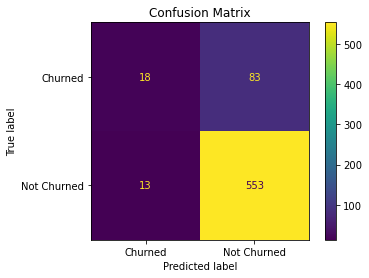

In [138]:
cm_display = ConfusionMatrixDisplay(cm, display_labels=logreg.classes_)
cm_display.plot()
plt.title('Confusion Matrix')

In [140]:
print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

     Churned       0.58      0.18      0.27       101
 Not Churned       0.87      0.98      0.92       566

    accuracy                           0.86       667
   macro avg       0.73      0.58      0.60       667
weighted avg       0.83      0.86      0.82       667



Class order: ['Churned' 'Not Churned']
AUC: 0.8314732533324003


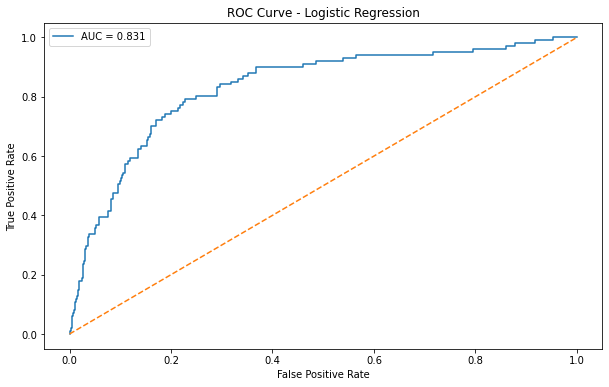

In [156]:
from sklearn.metrics import roc_curve, auc

print("Class order:", logreg.classes_)

churn_index = list(logreg.classes_).index('Churned')
y_prob = logreg.predict_proba(X_test_full)[:, churn_index]

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Churned')
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### The model achieved high accuracy but low recall for churn, indicating class imbalance.

## Class Imbalance 

In [170]:
y_train.value_counts(normalize=True)

Not Churned    0.856714
Churned        0.143286
Name: churn, dtype: float64

## Smote

In [171]:
from imblearn.over_sampling import SMOTE


# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_full, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_sm.value_counts())

Before SMOTE:
Not Churned    2284
Churned         382
Name: churn, dtype: int64

After SMOTE:
Not Churned    2284
Churned        2284
Name: churn, dtype: int64


In [164]:
# Train model
logreg_sm = LogisticRegression(solver='liblinear')
logreg_sm.fit(X_train_sm, y_train_sm)

# Predictions
y_train_preds_sm = logreg_sm.predict(X_train_sm)
y_test_preds_sm = logreg_sm.predict(X_test_full)

In [165]:
# Accuracy
print("\nTrain Accuracy with SMOTE:", accuracy_score(y_train_sm, y_train_preds_sm))
print("Test Accuracy with SMOTE:", accuracy_score(y_test, y_test_preds_sm))



Train Accuracy with SMOTE: 0.772985989492119
Test Accuracy with SMOTE: 0.7841079460269865


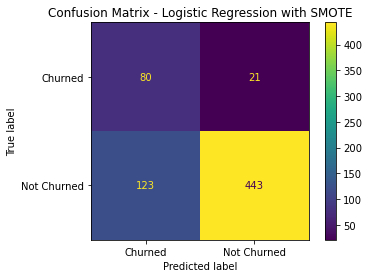

In [166]:
# Confusion Matrix
cm_sm = confusion_matrix(y_test, y_test_preds_sm, labels=logreg_sm.classes_)
disp_sm = ConfusionMatrixDisplay(confusion_matrix=cm_sm, display_labels=logreg_sm.classes_)
disp_sm.plot()
plt.title("Confusion Matrix - Logistic Regression with SMOTE")
plt.show()


In [167]:
# Classification Report
print("\nClassification Report - Logistic Regression with SMOTE")
print(classification_report(y_test, y_test_preds_sm))



Classification Report - Logistic Regression with SMOTE
              precision    recall  f1-score   support

     Churned       0.39      0.79      0.53       101
 Not Churned       0.95      0.78      0.86       566

    accuracy                           0.78       667
   macro avg       0.67      0.79      0.69       667
weighted avg       0.87      0.78      0.81       667




Class order: ['Churned' 'Not Churned']
AUC with SMOTE: 0.8358814680054578


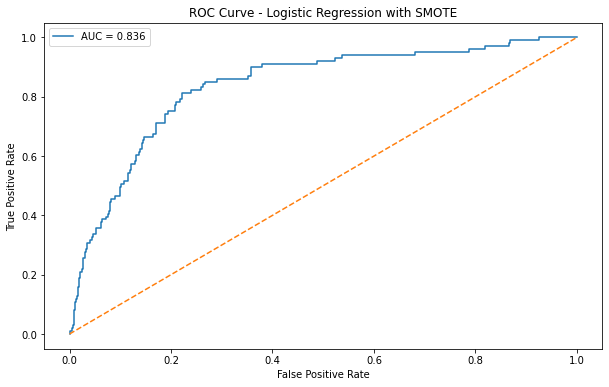

In [168]:
# ROC Curve + AUC
print("\nClass order:", logreg_sm.classes_)

churn_index = list(logreg_sm.classes_).index('Churned')
y_prob_sm = logreg_sm.predict_proba(X_test_full)[:, churn_index]

fpr_sm, tpr_sm, thresholds_sm = roc_curve(y_test, y_prob_sm, pos_label='Churned')
roc_auc_sm = auc(fpr_sm, tpr_sm)

print("AUC with SMOTE:", roc_auc_sm)

plt.figure(figsize=(10, 6))
plt.plot(fpr_sm, tpr_sm, label=f"AUC = {roc_auc_sm:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression with SMOTE")
plt.legend()
plt.show()

### After applying SMOTE, recall improved significantly, showing better detection of churned customers.

## Decision Tree (Without SMOTE)

In [185]:
from sklearn.tree import DecisionTreeClassifier

# Train model with hyperparameters
dt = DecisionTreeClassifier(
    criterion='entropy',   # use entropy / information gain
    max_depth=5,           # controls tree depth
    min_samples_split=10,  # minimum samples to split
    min_samples_leaf=5,    # minimum samples in a leaf
    random_state=42
)

dt.fit(X_train_full, y_train)



DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [181]:
# Predictions
y_train_preds_dt = dt.predict(X_train_full)
y_test_preds_dt = dt.predict(X_test_full)

# Accuracy
print("Train Accuracy - Decision Tree:", accuracy_score(y_train, y_train_preds_dt))
print("Test Accuracy - Decision Tree:", accuracy_score(y_test, y_test_preds_dt))

Train Accuracy - Decision Tree: 0.9486121530382595
Test Accuracy - Decision Tree: 0.9385307346326837


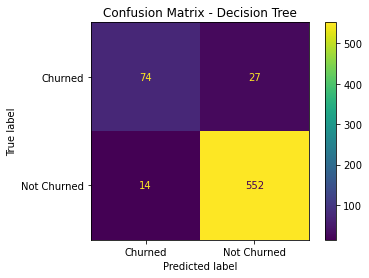


Classification Report - Decision Tree
              precision    recall  f1-score   support

     Churned       0.84      0.73      0.78       101
 Not Churned       0.95      0.98      0.96       566

    accuracy                           0.94       667
   macro avg       0.90      0.85      0.87       667
weighted avg       0.94      0.94      0.94       667



In [183]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_test_preds_dt, labels=dt.classes_)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt.classes_)
disp_dt.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Classification Report
print("\nClassification Report - Decision Tree")
print(classification_report(y_test, y_test_preds_dt))


Class order: ['Churned' 'Not Churned']
AUC - Decision Tree: 0.9065790854703845


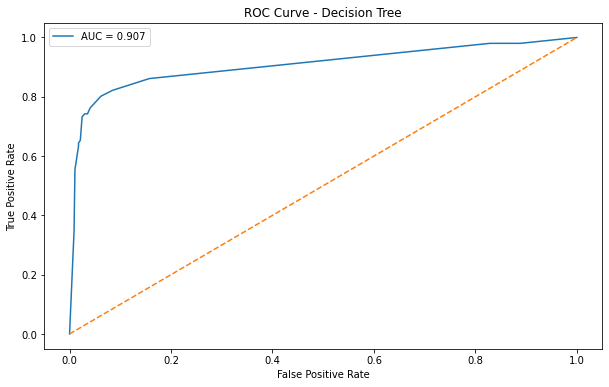

In [186]:
# ROC Curve + AUC
print("\nClass order:", dt.classes_)

churn_index_dt = list(dt.classes_).index('Churned')
y_prob_dt = dt.predict_proba(X_test_full)[:, churn_index_dt]

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt, pos_label='Churned')
roc_auc_dt = auc(fpr_dt, tpr_dt)

print("AUC - Decision Tree:", roc_auc_dt)

plt.figure(figsize=(10, 6))
plt.plot(fpr_dt, tpr_dt, label=f"AUC = {roc_auc_dt:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

## Decision Tree (With SMOTE)

In [188]:
# Train model with hyperparameters on SMOTE data
dt_sm = DecisionTreeClassifier(
    criterion='entropy',   # use entropy / information gain
    max_depth=5,           # controls tree depth
    min_samples_split=10,  # minimum samples to split
    min_samples_leaf=5,    # minimum samples in a leaf
    random_state=42

)

dt_sm.fit(X_train_sm, y_train_sm)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [189]:
# Predictions
y_train_preds_dt_sm = dt_sm.predict(X_train_sm)
y_test_preds_dt_sm = dt_sm.predict(X_test_full)

# Accuracy
print("Train Accuracy - Decision Tree with SMOTE:", accuracy_score(y_train_sm, y_train_preds_dt_sm))
print("Test Accuracy - Decision Tree with SMOTE:", accuracy_score(y_test, y_test_preds_dt_sm))

Train Accuracy - Decision Tree with SMOTE: 0.897985989492119
Test Accuracy - Decision Tree with SMOTE: 0.800599700149925


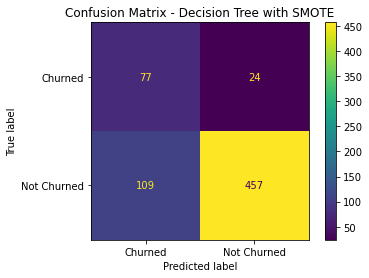


Classification Report - Decision Tree with SMOTE
              precision    recall  f1-score   support

     Churned       0.41      0.76      0.54       101
 Not Churned       0.95      0.81      0.87       566

    accuracy                           0.80       667
   macro avg       0.68      0.78      0.70       667
weighted avg       0.87      0.80      0.82       667



In [190]:
# Confusion Matrix
cm_dt_sm = confusion_matrix(y_test, y_test_preds_dt_sm, labels=dt_sm.classes_)
disp_dt_sm = ConfusionMatrixDisplay(confusion_matrix=cm_dt_sm, display_labels=dt_sm.classes_)
disp_dt_sm.plot()
plt.title("Confusion Matrix - Decision Tree with SMOTE")
plt.show()

# Classification Report
print("\nClassification Report - Decision Tree with SMOTE")
print(classification_report(y_test, y_test_preds_dt_sm))


Class order: ['Churned' 'Not Churned']
AUC - Decision Tree with SMOTE: 0.8097645453591296


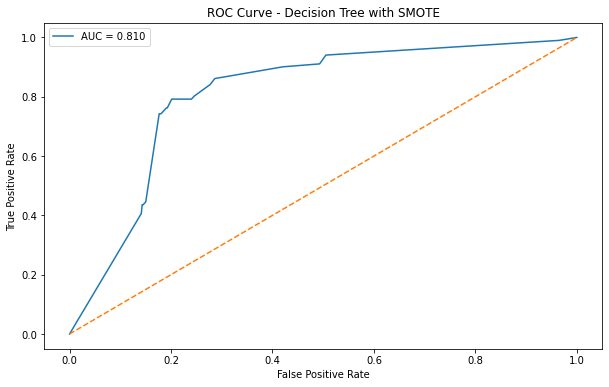

In [191]:
# ROC Curve + AUC
print("\nClass order:", dt_sm.classes_)

churn_index_dt_sm = list(dt_sm.classes_).index('Churned')
y_prob_dt_sm = dt_sm.predict_proba(X_test_full)[:, churn_index_dt_sm]

fpr_dt_sm, tpr_dt_sm, thresholds_dt_sm = roc_curve(y_test, y_prob_dt_sm, pos_label='Churned')
roc_auc_dt_sm = auc(fpr_dt_sm, tpr_dt_sm)

print("AUC - Decision Tree with SMOTE:", roc_auc_dt_sm)

plt.figure(figsize=(10, 6))
plt.plot(fpr_dt_sm, tpr_dt_sm, label=f"AUC = {roc_auc_dt_sm:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree with SMOTE")
plt.legend()
plt.show()

## Final Conclusion

In this project, multiple classification models were developed to predict customer churn, including Logistic Regression (with and without SMOTE) and Decision Tree models (with and without SMOTE).

The initial Logistic Regression model achieved high accuracy (~86%) but performed poorly in identifying churned customers, with very low recall (~18%). This indicated a strong class imbalance problem.

After applying SMOTE, Logistic Regression significantly improved recall (~79%), but overall accuracy decreased (~78%), showing a trade-off between detecting churn and maintaining overall performance.

The Decision Tree model without SMOTE achieved the best overall performance, with high accuracy (~94%), strong AUC (~0.91), and a good balance between precision and recall (recall ~73%). This indicates the model is both accurate and reasonably effective at detecting churn.

Applying SMOTE to the Decision Tree slightly improved recall (~76%), but reduced accuracy (~80%) and AUC (~0.81), suggesting that the original model already handled the data well.

Overall, the Decision Tree without SMOTE provided the best balance between performance metrics and generalization ability.

## Selected Model

The Decision Tree model without SMOTE was selected as the final model.

This model was chosen because it achieved the highest overall accuracy (~94%), the strongest AUC (~0.91), and maintained a good balance between precision and recall for churned customers.

Although SMOTE improved recall in some models, it reduced overall performance. The selected model provides the best trade-off between correctly identifying churned customers and maintaining high predictive accuracy.

Therefore, the Decision Tree without SMOTE is the most suitable model for this business problem.

## Recommendations

Based on the model results, the following recommendations are proposed:

• Focus on Churn Prediction  
→ Use the Decision Tree model to identify customers likely to churn.

• Improve Customer Retention  
→ Offer discounts, promotions, or better support to at-risk customers.

• Monitor Model Performance  
→ Regularly update the model with new data.

• Consider Trade-offs  
→ Balance between accuracy and recall based on business needs.

• Analyze Important Features  
→ Identify key factors causing churn and take action.

• Future Improvements  
→ Try advanced models like Random Forest for better performance..  